# Notebook 3: Quantum Clustering Prototype (Phase 3, Cells 16-19)

This notebook isolates quantum simulation work (slow/noisy by nature) from classical baselines.

Scope:
- Amplitude + angle encoding kernel construction
- Hybrid Lloyd-style kernel k-means loop (adiabatic-inspired medoid update)
- Kernel distance oracle for assignment
- Small-scale run: 300 samples, 5 qubits (32-d compatible)
- MDS visualization: quantum vs classical clusters

Primary outputs:
- `quantum_labels.npy`
- `kernel_matrix.npz`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import MDS
from sklearn.preprocessing import normalize

try:
    from qiskit import QuantumCircuit
    from qiskit.quantum_info import Statevector
    QISKIT_AVAILABLE = True
except Exception:
    QISKIT_AVAILABLE = False

PHASE1_DIR = Path("data/processed_32m_phase1")
PHASE2_DIR = Path("data/processed_32m_phase2")
OUTPUT_DIR = Path("data/processed_32m_phase3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LATENT_PATH = PHASE1_DIR / "latent_embeddings.npy"
CLASSICAL_LABELS_PATH = PHASE2_DIR / "classical_clusters.npy"

SEED = 42
N_QUBITS = 5
TARGET_DIM = 2 ** N_QUBITS
SAMPLE_SIZE = 300
K_QUANTUM = 6
MAX_ITERS = 12

X_full = np.load(LATENT_PATH).astype(np.float32)
classical_labels_full = np.load(CLASSICAL_LABELS_PATH).astype(np.int32) if CLASSICAL_LABELS_PATH.exists() else None

rng = np.random.default_rng(SEED)
n_available = X_full.shape[0]
sample_size = min(SAMPLE_SIZE, n_available)
sample_idx = np.sort(rng.choice(np.arange(n_available), size=sample_size, replace=False))

X = X_full[sample_idx]

if X.shape[1] >= TARGET_DIM:
    X = X[:, :TARGET_DIM]
else:
    X = np.pad(X, ((0, 0), (0, TARGET_DIM - X.shape[1])), mode="constant")

X_amp = normalize(X, norm="l2", axis=1).astype(np.float32)
X_angle = np.clip(X, -3.0, 3.0)
X_angle = ((X_angle - X_angle.min(axis=0, keepdims=True)) / (X_angle.ptp(axis=0, keepdims=True) + 1e-8)) * np.pi

print(f"Qiskit available: {QISKIT_AVAILABLE}")
print(f"Sample shape for quantum prototype: {X.shape}")
print(f"Qubits: {N_QUBITS}, target dim: {TARGET_DIM}")

C:\Users\acolumban\AppData\Local\Temp\ipykernel_24520\259314992.py:9: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


Qiskit available: True
Sample shape for quantum prototype: (300, 32)
Qubits: 5, target dim: 32


In [2]:
# Cell 17: Build quantum-inspired kernel matrix (amplitude + angle encoding)
def angle_statevector(x_angles):
    if QISKIT_AVAILABLE:
        qc = QuantumCircuit(N_QUBITS)
        for q in range(N_QUBITS):
            qc.ry(float(x_angles[q]), q)
        return Statevector.from_instruction(qc).data.astype(np.complex64)

    single_states = []
    for theta in x_angles[:N_QUBITS]:
        single_states.append(np.array([np.cos(theta / 2.0), np.sin(theta / 2.0)], dtype=np.complex64))

    out = single_states[0]
    for st in single_states[1:]:
        out = np.kron(out, st)
    return out


def amp_statevector(x_amp):
    vec = x_amp.astype(np.complex64)
    nrm = np.linalg.norm(vec) + 1e-12
    vec = vec / nrm
    return vec


def fidelity(a, b):
    return float(np.abs(np.vdot(a, b)) ** 2)


n = X.shape[0]
angle_states = [angle_statevector(X_angle[i]) for i in range(n)]
amp_states = [amp_statevector(X_amp[i]) for i in range(n)]

kernel_matrix = np.zeros((n, n), dtype=np.float32)
for i in range(n):
    kernel_matrix[i, i] = 1.0
    for j in range(i + 1, n):
        k_amp = fidelity(amp_states[i], amp_states[j])
        k_ang = fidelity(angle_states[i], angle_states[j])
        kval = 0.5 * (k_amp + k_ang)
        kernel_matrix[i, j] = kval
        kernel_matrix[j, i] = kval

np.savez_compressed(OUTPUT_DIR / "kernel_matrix.npz", kernel=kernel_matrix, sample_idx=sample_idx)
print(f"Kernel matrix shape: {kernel_matrix.shape}")
print(f"Saved: {OUTPUT_DIR / 'kernel_matrix.npz'}")

Kernel matrix shape: (300, 300)
Saved: data\processed_32m_phase3\kernel_matrix.npz


In [3]:
# Cell 18: Hybrid Lloyd-style quantum kernel k-means (distance oracle)
def run_hybrid_quantum_lloyd(kernel, k=6, max_iters=10, seed=42):
    rng_local = np.random.default_rng(seed)
    n_points = kernel.shape[0]

    centers = rng_local.choice(n_points, size=k, replace=False)
    labels = np.zeros(n_points, dtype=np.int32)

    for _ in range(max_iters):
        old_labels = labels.copy()

        d2 = np.zeros((n_points, k), dtype=np.float32)
        diag = np.diag(kernel)
        for c in range(k):
            center_idx = centers[c]
            d2[:, c] = diag + kernel[center_idx, center_idx] - 2.0 * kernel[:, center_idx]

        labels = np.argmin(d2, axis=1).astype(np.int32)

        new_centers = centers.copy()
        for c in range(k):
            members = np.where(labels == c)[0]
            if len(members) == 0:
                new_centers[c] = int(rng_local.integers(0, n_points))
                continue

            subk = kernel[np.ix_(members, members)]
            scores = subk.mean(axis=1)
            medoid_local = int(np.argmax(scores))
            new_centers[c] = int(members[medoid_local])

        centers = new_centers
        if np.array_equal(labels, old_labels):
            break

    return labels, centers


quantum_labels, quantum_centers = run_hybrid_quantum_lloyd(
    kernel=kernel_matrix,
    k=K_QUANTUM,
    max_iters=MAX_ITERS,
    seed=SEED,
)

np.save(OUTPUT_DIR / "quantum_labels.npy", quantum_labels.astype(np.int32))
print(f"Unique quantum clusters: {np.unique(quantum_labels).size}")
print(f"Saved: {OUTPUT_DIR / 'quantum_labels.npy'}")

Unique quantum clusters: 6
Saved: data\processed_32m_phase3\quantum_labels.npy


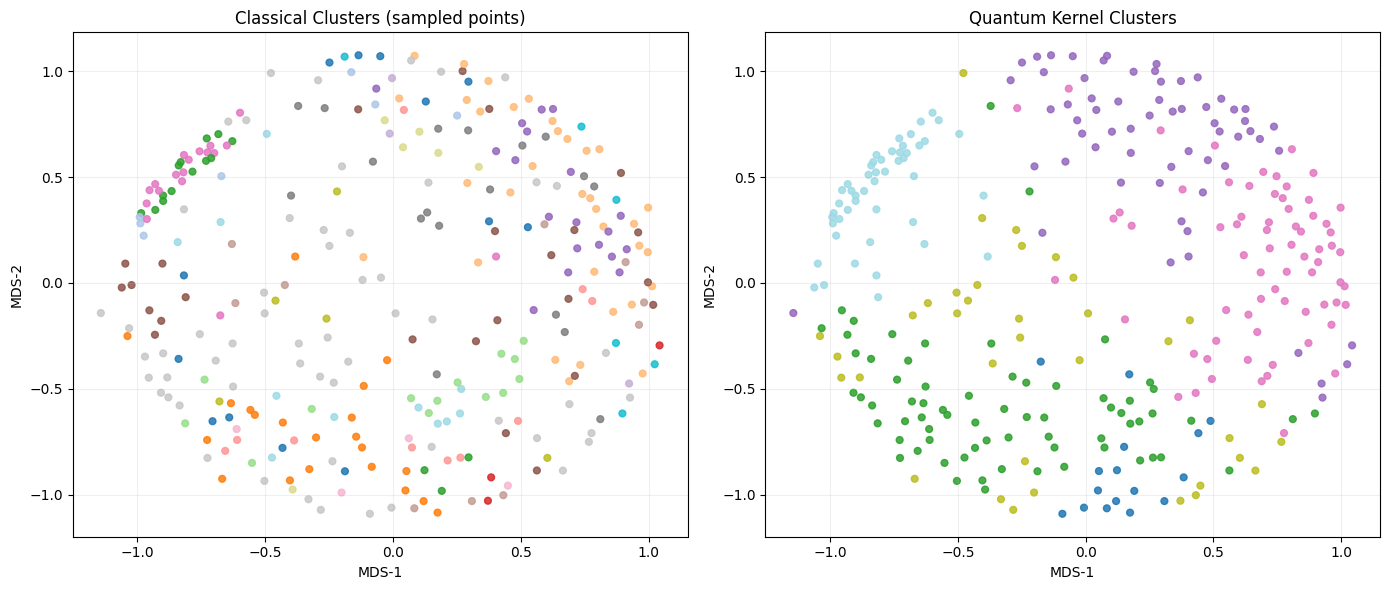

Saved outputs:
- data\processed_32m_phase3\quantum_labels.npy
- data\processed_32m_phase3\kernel_matrix.npz


In [4]:
# Cell 19: MDS visualization (quantum vs classical)
distance = np.sqrt(np.clip(np.diag(kernel_matrix)[:, None] + np.diag(kernel_matrix)[None, :] - 2.0 * kernel_matrix, 0.0, None))
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=SEED, n_init=4, max_iter=300)
X_2d = mds.fit_transform(distance)

if classical_labels_full is not None and len(classical_labels_full) >= np.max(sample_idx) + 1:
    classical_subset = classical_labels_full[sample_idx]
else:
    classical_subset = np.zeros_like(quantum_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=classical_subset, s=24, cmap="tab20", alpha=0.85)
axes[0].set_title("Classical Clusters (sampled points)")
axes[0].set_xlabel("MDS-1")
axes[0].set_ylabel("MDS-2")
axes[0].grid(alpha=0.2)

sc2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=quantum_labels, s=24, cmap="tab20", alpha=0.85)
axes[1].set_title("Quantum Kernel Clusters")
axes[1].set_xlabel("MDS-1")
axes[1].set_ylabel("MDS-2")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("Saved outputs:")
print(f"- {OUTPUT_DIR / 'quantum_labels.npy'}")
print(f"- {OUTPUT_DIR / 'kernel_matrix.npz'}")